# KV Cache

Placeholder notebook. Companion code for the blog post [The KV Cache: Build It, Break It, Measure It](https://maitreyasuin.github.io/blog/posts/kv-cache/index.html).


**Cell 1 - setup**

In [1]:
# GPU: Runtime → Change runtime type → T4
!pip -q install tiktoken transformers
import math, time, torch, torch.nn as nn, torch.nn.functional as F
from dataclasses import dataclass
torch.manual_seed(0)
device = "cuda"
print(torch.__version__, torch.version.cuda, torch.cuda.get_device_name())


import tiktoken
enc = tiktoken.get_encoding("gpt2")
prompt = torch.tensor([enc.encode("The key to fast inference is")], device=device)

2.11.0+cu128 12.8 Tesla T4


**Cell 2 - the model**

In [2]:
@dataclass
class GPTConfig:
    block_size: int = 1024   # GPT-2 max context
    vocab_size: int = 50257
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head = cfg.n_head
        self.c_attn = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)  # fused QKV
        self.c_proj = nn.Linear(cfg.n_embd, cfg.n_embd)

    def forward(self, x, cache=None):
        B, T, C = x.shape
        # One linear layer produces Q, K, V together:
        #   x: (B, T, C) → qkv: (B, T, 3C) → split → q, k, v: each (B, T, C)
        q, k, v = self.c_attn(x).split(C, dim=2)
        # Reshape for multi-head attention: (B, T, C) → (B, H, T, D_h).
        # Heads become a batch-like dim so each head attends independently.
        q, k, v = (t.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
                   for t in (q, k, v))
        if cache is not None:
            # Decode: this call's k,v cover only the NEW T tokens.
            # Prepend history along the sequence dim (dim=2 in (B,H,T,D_h)).
            k_past, v_past = cache          # each (B, H, past, D_h)
            k = torch.cat([k_past, k], dim=2)   # (B, H, past+T, D_h)
            v = torch.cat([v_past, v], dim=2)
            # ^ Simple, correct, and secretly expensive - see §8.
        # Masking (the full story is §5, bug 2):
        #   prefill  → square T×T attention → causal mask ON
        #   decode   → 1 query vs past+1 keys → everything IS the past; no mask needed.
        # is_causal=True during decode is not just unnecessary - it's WRONG:
        # SDPA aligns non-square causal masks top-left, hiding nearly the whole cache.
        y = F.scaled_dot_product_attention(q, k, v, is_causal=(cache is None))
        # (B, H, T, D_h) → (B, T, H, D_h) → (B, T, C).
        # contiguous() because transpose changed strides and view() needs flat memory.
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc   = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        self.c_proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
        self.act    = nn.GELU(approximate="tanh")   # GPT-2 uses tanh-GELU
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln_1, self.attn = nn.LayerNorm(cfg.n_embd), CausalSelfAttention(cfg)
        self.ln_2, self.mlp  = nn.LayerNorm(cfg.n_embd), MLP(cfg)
    def forward(self, x, cache=None):
        a, cache = self.attn(self.ln_1(x), cache)
        x = x + a
        x = x + self.mlp(self.ln_2(x))
        return x, cache

class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(cfg.vocab_size, cfg.n_embd),
            wpe = nn.Embedding(cfg.block_size, cfg.n_embd),
            h   = nn.ModuleList(Block(cfg) for _ in range(cfg.n_layer)),
            ln_f= nn.LayerNorm(cfg.n_embd),
        ))
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.transformer.wte.weight   # weight tying

    def forward(self, idx, caches=None):
        B, T = idx.shape
        # Every layer has cached the same number of tokens;
        # caches[0][0] is layer 0's key cache: (B, H, past, D_h) → read `past` off dim 2.
        past = 0 if caches is None else caches[0][0].size(2)
        assert past + T <= self.config.block_size
        # POSITION OFFSET - the #1 cache bug (§5): token t must get position
        # embedding t, not 0. During decode T=1, so without the offset every
        # generated token would sit at position 0.
        pos = torch.arange(past, past + T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        new_caches = []
        for i, block in enumerate(self.transformer.h):
            x, c = block(x, None if caches is None else caches[i])
            new_caches.append(c)
        x = self.transformer.ln_f(x)
        return self.lm_head(x), new_caches

**Cell 3 - load the real GPT-2 weights**

In [3]:
@classmethod
def from_pretrained(cls):
    """Load HF GPT-2 (124M) weights into this implementation."""
    from transformers import GPT2LMHeadModel
    model = cls(GPTConfig())
    sd = model.state_dict()
    hf = GPT2LMHeadModel.from_pretrained("gpt2").state_dict()
    # HF stores these linear layers as Conv1D → weights are transposed
    transposed = ("attn.c_attn.weight", "attn.c_proj.weight",
                  "mlp.c_fc.weight", "mlp.c_proj.weight")
    with torch.no_grad():
        for k in hf:
            if k.endswith(".attn.masked_bias") or k.endswith(".attn.bias"):
                continue                      # causal-mask buffers, not params
            w = hf[k].t() if any(k.endswith(t) for t in transposed) else hf[k]
            sd[k].copy_(w)
    return model

GPT.from_pretrained = from_pretrained
model = GPT.from_pretrained().to(device).eval()
print(sum(p.numel() for p in model.parameters())/1e6, "M params")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

124.439808 M params


**Cell 4 - two generation loops**

In [4]:
def timed(fn):
    torch.cuda.synchronize(); t0 = time.perf_counter()
    out = fn()
    torch.cuda.synchronize()
    return out, time.perf_counter() - t0

@torch.inference_mode()
def generate_no_cache(model, idx, max_new_tokens):
    """The naive loop: full forward over the whole sequence, every step."""
    per_step = []
    for _ in range(max_new_tokens):
        (logits, _), dt = timed(lambda: model(idx[:, -model.config.block_size:]))
        idx = torch.cat([idx, logits[:, -1].argmax(-1, keepdim=True)], dim=1)
        per_step.append(dt)
    return idx, per_step

@torch.inference_mode()
def generate_with_cache(model, idx, max_new_tokens):
    """Prefill once over the prompt, then feed ONE token per step."""
    per_step = []
    (logits, caches), t_prefill = timed(lambda: model(idx))       # PREFILL
    nxt = logits[:, -1].argmax(-1, keepdim=True)
    out = [idx, nxt]
    for _ in range(max_new_tokens - 1):                            # DECODE
        (logits, caches), dt = timed(lambda: model(nxt, caches))
        nxt = logits[:, -1].argmax(-1, keepdim=True)
        out.append(nxt)
        per_step.append(dt)
    return torch.cat(out, dim=1), per_step, t_prefill

**Cell 5a - logit-level check **

In [5]:
@torch.inference_mode()
def assert_cached_logits_match(model, prompt):
    logits_full, caches = model(prompt)                     # prefill
    nxt = logits_full[:, -1].argmax(-1, keepdim=True)
    logits_ref, _ = model(torch.cat([prompt, nxt], dim=1))  # recompute from scratch
    logits_inc, _ = model(nxt, caches)                      # one cached step
    torch.testing.assert_close(logits_inc[:, -1], logits_ref[:, -1],
                               rtol=1e-5, atol=1e-5)
    print("logit exactness ✓")

model_fp32 = model.float()
assert_cached_logits_match(model_fp32, prompt)

logit exactness ✓


**Cell 5b**

In [6]:
a, _     = generate_no_cache(model_fp32, prompt.clone(), 100)
b, _, _  = generate_with_cache(model_fp32, prompt.clone(), 100)
assert torch.equal(a, b), "cache changed the output!"
print("greedy exactness ✓ :", enc.decode(a[0].tolist())[:120], "...")

greedy exactness ✓ : The key to fast inference is to know what the data is about.

The first thing to know is that the data is not a single p ...


**Bug 1 **

In [7]:
class PositionBuggyGPT(GPT):
    """The bug, isolated: positions restart at 0 every forward call."""
    def forward(self, idx, caches=None):
        B, T = idx.shape
        past = 0 if caches is None else caches[0][0].size(2)
        pos = torch.arange(0, T, device=idx.device)          # ← BUG: no offset
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        new_caches = []
        for i, block in enumerate(self.transformer.h):
            x, c = block(x, None if caches is None else caches[i])
            new_caches.append(c)
        return self.lm_head(self.transformer.ln_f(x)), new_caches

buggy = PositionBuggyGPT(GPTConfig()).to(device).float().eval()
buggy.load_state_dict(model_fp32.state_dict())

a, _    = generate_no_cache(buggy, prompt.clone(), 40)       # no cache → bug dormant
b, _, _ = generate_with_cache(buggy, prompt.clone(), 40)     # cached  → bug live
print("outputs equal?", torch.equal(a, b))                   # False
print("no cache:", enc.decode(a[0].tolist()))
print("cached  :", enc.decode(b[0].tolist()))                # fluent, then unmoored
# outputs equal? False
# no cache: The key to fast inference is to know what the data is about.

# The first thing to know is that the data is not a single point. It is a collection of points.

# The second thing to know is
# cached  : The key to fast inference is to the the,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

outputs equal? False
no cache: The key to fast inference is to know what the data is about.

The first thing to know is that the data is not a single point. It is a collection of points.

The second thing to know is
cached  : The key to fast inference is to the the,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


**Bug 2**

In [8]:
B, H, past, Dh = 1, 12, 64, 64
q = torch.randn(B, H, 1, Dh, device=device)          # one decode query
k = torch.randn(B, H, past + 1, Dh, device=device)   # full cache
v = torch.randn(B, H, past + 1, Dh, device=device)

right = F.scaled_dot_product_attention(q, k, v, is_causal=False)
wrong = F.scaled_dot_product_attention(q, k, v, is_causal=True)

# What did the wrong one compute? Attention to ONLY the first key:
only_first = v[:, :, :1, :]
print((wrong - only_first).abs().max().item())   # ~0  ← it ignored 64 of 65 keys
print((right - wrong).abs().max().item())        # large
# 0.0
# 3.039318561553955

0.0
3.039318561553955


**Cell 6 - the race**

In [9]:
model = model.half().eval()
print(torch.__version__, torch.version.cuda, torch.cuda.get_device_name())

def reset_mem():  torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
def peak_mb():    return torch.cuda.max_memory_allocated() / 2**20

for _ in range(3):                                   # warmup: CUDA context, kernels, allocator
    generate_with_cache(model, torch.randint(0, 50257, (1, 128), device=device), 16)

rows = []
for plen in (16, 128, 512):
    prompt = torch.randint(0, 50257, (1, plen), device=device)
    n_new = 400 if plen <= 128 else 400              # keep plen+n_new < 1024
    reset_mem(); _, steps_nc      = generate_no_cache(model, prompt.clone(), n_new)
    reset_mem(); _, steps_c, tp   = generate_with_cache(model, prompt.clone(), n_new); mem_c = peak_mb()
    rows.append((plen, n_new, sum(steps_nc), tp + sum(steps_c),
                 sum(steps_nc)/(tp + sum(steps_c)), 1e3*sum(steps_c)/len(steps_c), mem_c))
for r in rows: print(r)

2.11.0+cu128 12.8 Tesla T4
(16, 400, 2.9925526759999457, 1.8130196640006488, 1.6505903026978281, 4.531713192984187, 767.873046875)
(128, 400, 3.141694397999345, 1.82670651499825, 1.7198681737894577, 4.562684563905209, 775.75)
(512, 400, 6.306519704999573, 1.8045137010011558, 3.4948583108572, 4.502018012534252, 834.35888671875)


**Cell 7**

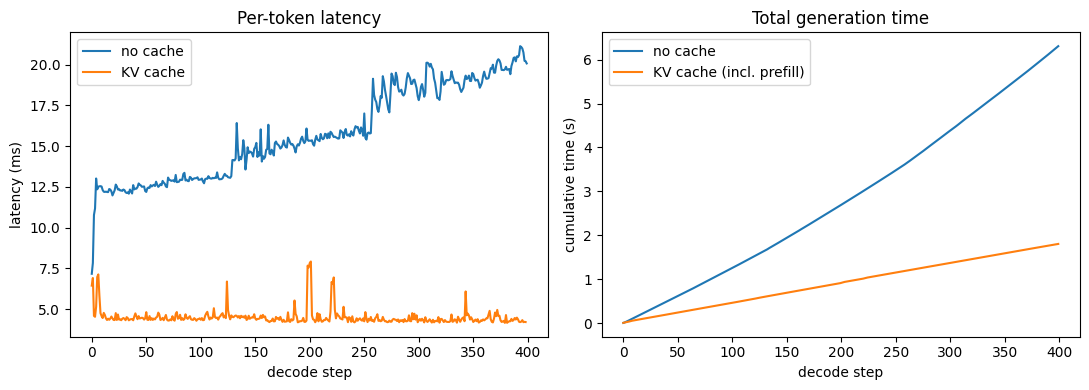

In [10]:
import numpy as np, matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([t*1e3 for t in steps_nc], label="no cache")
ax[0].plot([t*1e3 for t in steps_c],  label="KV cache")
ax[0].set(xlabel="decode step", ylabel="latency (ms)", title="Per-token latency")
ax[0].legend()
ax[1].plot(np.cumsum(steps_nc),              label="no cache")
ax[1].plot(np.cumsum([tp] + steps_c),        label="KV cache (incl. prefill)")
ax[1].set(xlabel="decode step", ylabel="cumulative time (s)", title="Total generation time")
ax[1].legend(); plt.tight_layout(); plt.savefig("latency.png", dpi=180)